In [5]:
#Data Manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Data Visualization import matplotlib.pyplot plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
#Splitting Dataset
from sklearn.model_selection import train_test_split
# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
#Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#Save Model
import pickle

In [6]:
df=pd.read_csv("/content/student_performance.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Student_ID       200 non-null    int64 
 1   Gender           200 non-null    object
 2   Age              200 non-null    int64 
 3   Study_Hours      200 non-null    int64 
 4   Attendance       200 non-null    int64 
 5   Previous_Score   200 non-null    int64 
 6   Assignments      200 non-null    int64 
 7   Extracurricular  200 non-null    object
 8   Final_Score      200 non-null    int64 
 9   Pass             200 non-null    object
dtypes: int64(7), object(3)
memory usage: 15.8+ KB


In [8]:
df.head()

,Student_ID,Gender,Age,Study_Hours,Attendance,Previous_Score,Assignments,Extracurricular,Final_Score,Pass
0,1,Female,22,2,77,72,58,No,54,Yes
1,2,Male,18,2,89,48,63,No,60,Yes
2,3,Male,20,4,77,75,68,No,60,Yes
3,4,Male,23,6,67,70,75,Yes,78,Yes
4,5,Male,18,3,72,80,99,No,70,Yes


In [9]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
Study_Hours,0
Attendance,0
Previous_Score,0
Assignments,0
Extracurricular,0
Final_Score,0
Pass,0


In [10]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [11]:
df.fillna(df.mode().iloc[0],inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.shape

(200, 10)

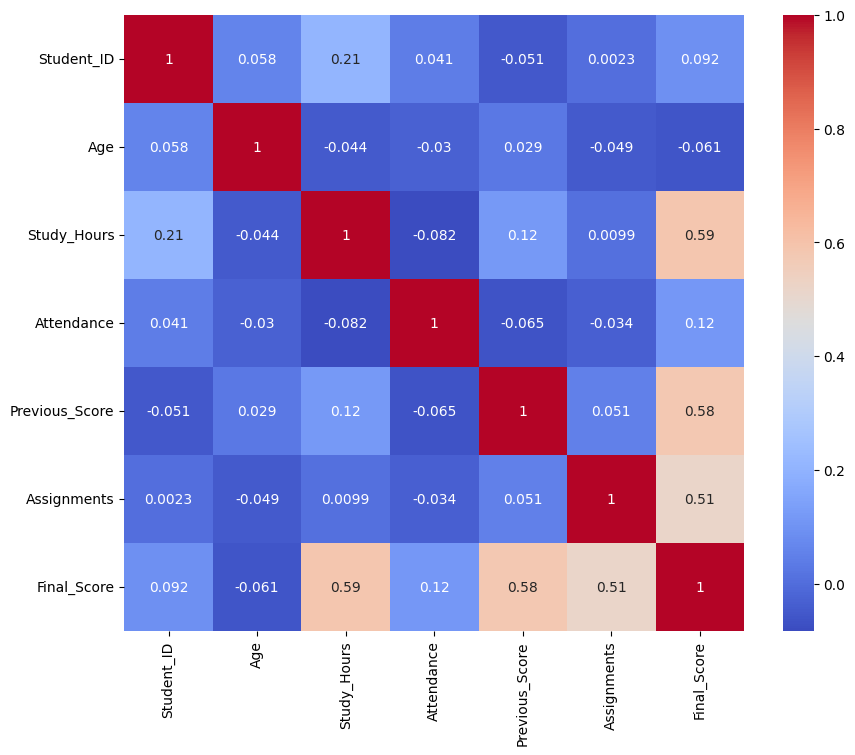

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

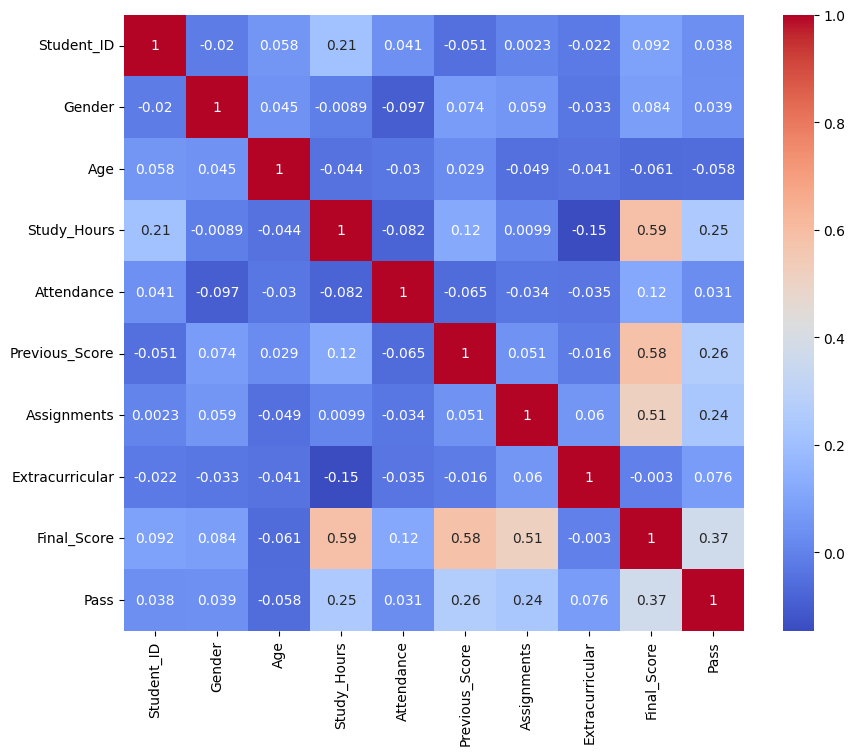

In [16]:
temp=df.copy()
le =LabelEncoder()
temp["Gender"]= le.fit_transform(temp["Gender"])
temp["Extracurricular"] = le.fit_transform(temp["Extracurricular"])
temp["Pass"] = le.fit_transform(temp["Pass"])
plt.figure(figsize=(10,8))
sns.heatmap(temp.corr(),
annot=True,
cmap="coolwarm")
plt.show()


<Axes: xlabel='Final_Score', ylabel='Count'>

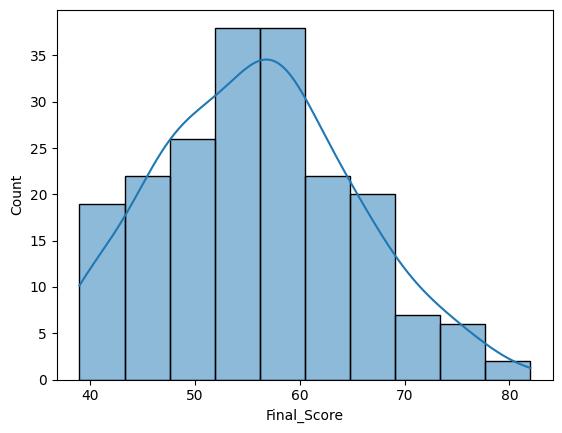

In [17]:
sns.histplot(df["Final_Score"], kde=True)


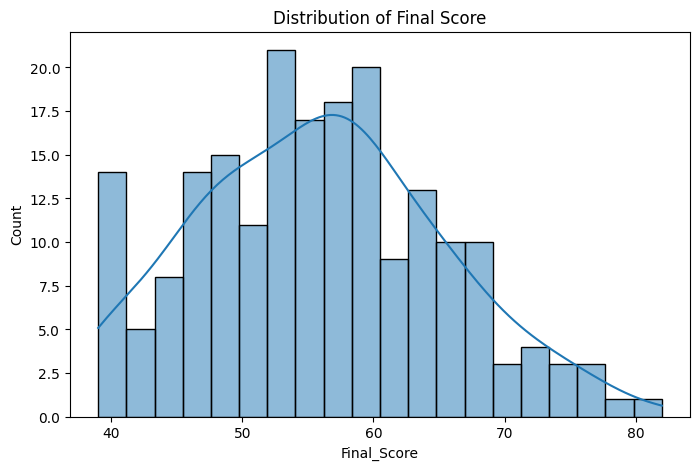

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["Final_Score"], bins=20, kde=True)
plt.title("Distribution of Final Score")
plt.show()

<Axes: xlabel='Attendance', ylabel='Final_Score'>

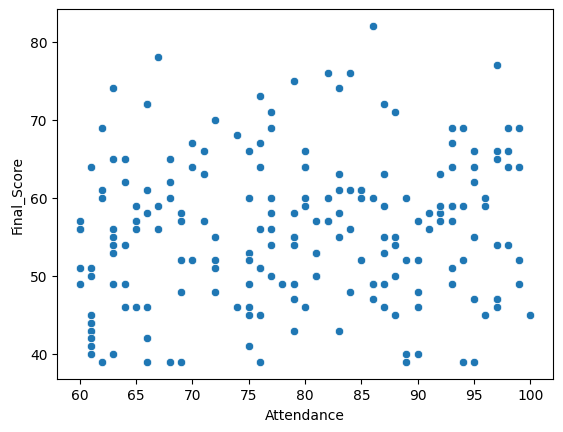

In [19]:
sns.scatterplot(x="Attendance", y="Final_Score", data=df)

<Axes: xlabel='Study_Hours', ylabel='Final_Score'>

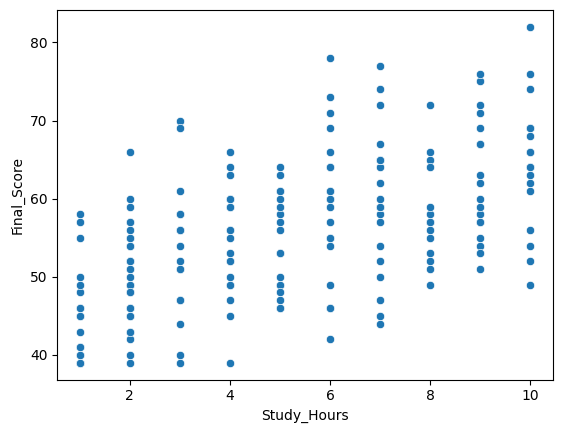

In [20]:
sns.scatterplot(x="Study_Hours", y="Final_Score", data=df)

<Axes: ylabel='Final_Score'>

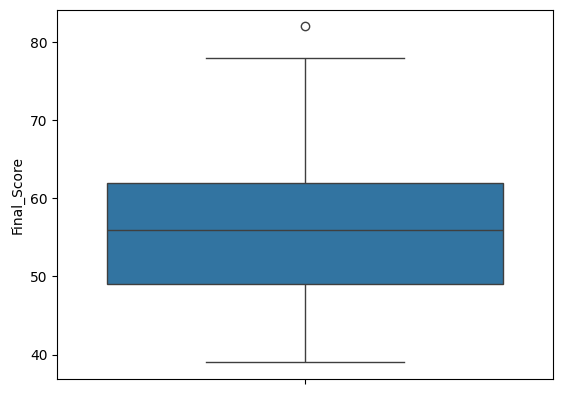

In [21]:
sns.boxplot(df["Final_Score"])

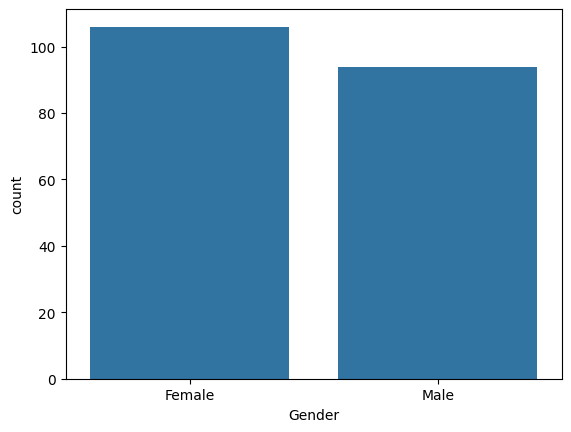

In [22]:
sns.countplot(x="Gender", data=df)
plt.show()

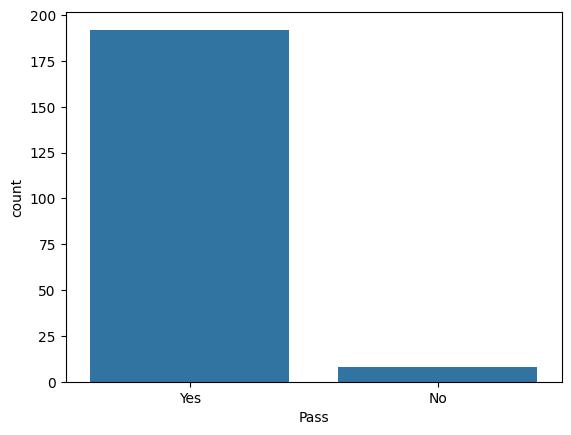

In [23]:
sns.countplot(x="Pass", data=df)
plt.show()

In [24]:
le=LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Extracurricular"] = le.fit_transform(df["Extracurricular"])
df["Pass"] = le.fit_transform(df["Pass"])

In [25]:
df.head()

,Student_ID,Gender,Age,Study_Hours,Attendance,Previous_Score,Assignments,Extracurricular,Final_Score,Pass
0,1,0,22,2,77,72,58,0,54,1
1,2,1,18,2,89,48,63,0,60,1
2,3,1,20,4,77,75,68,0,60,1
3,4,1,23,6,67,70,75,1,78,1
4,5,1,18,3,72,80,99,0,70,1


In [26]:
df.tail()

,Student_ID,Gender,Age,Study_Hours,Attendance,Previous_Score,Assignments,Extracurricular,Final_Score,Pass
195,196,1,17,9,66,56,57,0,72,1
196,197,1,18,7,63,80,83,0,65,1
197,198,0,17,6,98,53,45,0,66,1
198,199,1,17,10,85,54,55,0,61,1
199,200,1,24,6,76,96,65,1,73,1


In [27]:
x = df.drop(["Student_ID", "Final_Score"], axis=1)
y = df["Final_Score"]

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42)

In [29]:
lr=LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [30]:
lr_pred=lr.predict(x_test)

In [31]:
mae = mean_absolute_error(y_test, lr_pred)
mse = mean_squared_error(y_test, lr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_pred) #Percentage of variance [closer to 1 is better]
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.0493130745740153
RMSE: 1.269471357902265
R2: 0.9840612452748895


In [32]:
dt = DecisionTreeRegressor (random_state=42)
dt.fit(x_train, y_train)
dt_pred = dt.predict(x_test)
print(r2_score(y_test, dt_pred))

0.7027970947303354


In [33]:
rf=RandomForestRegressor (
n_estimators=100,
random_state=42
)
rf.fit(x_train, y_train)
rf_pred=rf.predict(x_test)
print(r2_score(y_test, rf_pred))

0.9006803523412146


In [34]:
models = {
"Linear Regression": lr,
"Decision Tree": dt,
"Random Forest": rf
}
for name, model in models.items():
  pred=model.predict(x_test)
  print(name)
  print("R2:", r2_score(y_test, pred))
  print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

Linear Regression
R2: 0.9840612452748895
RMSE: 1.269471357902265
Decision Tree
R2: 0.7027970947303354
RMSE: 5.481788029466299
Random Forest
R2: 0.9006803523412146
RMSE: 3.168934757927339


In [36]:
importance =pd.DataFrame ({
"Feature": x.columns,
"Importance": rf.feature_importances_
})

importance = importance.sort_values(
by="Importance",
ascending =False
)
print(importance)

           Feature  Importance
4   Previous_Score    0.313230
2      Study_Hours    0.297471
5      Assignments    0.266871
3       Attendance    0.055692
1              Age    0.039934
7             Pass    0.013990
6  Extracurricular    0.007517
0           Gender    0.005295


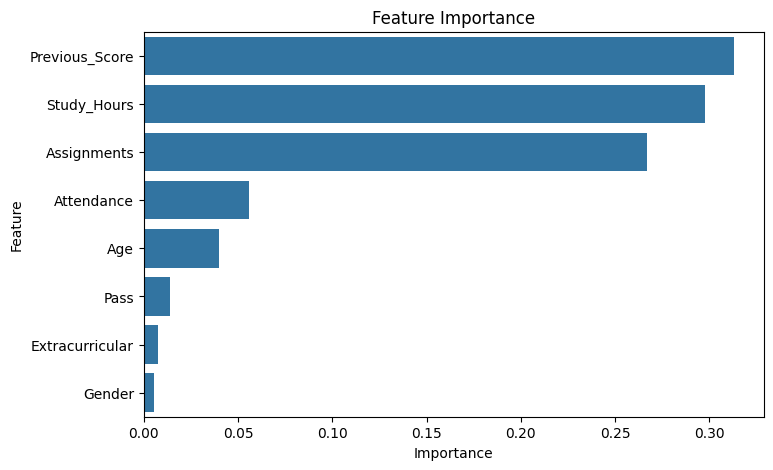

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(data=importance,
x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

In [38]:
pickle.dump(rf, open("student_score_predictor.pkl", "wb"))

In [39]:
model = pickle.load(open("student_score_predictor.pkl", "rb"))

In [43]:
sample=pd.DataFrame({
"Gender": [1],
"Age": [20],
"Study_Hours": [6],
"Attendance": [90],
"Previous_Score": [82],
"Assignments": [8],
"Extracurricular": [1],
"Pass": [1]
})

prediction = model.predict(sample)
print("Predicted Final Score:", prediction[0])

Predicted Final Score: 55.37


In [47]:
pickle.dump(lr, open("student_score_predictor.pkl", "wb"))

In [48]:
model1= pickle.load(open("student_score_predictor.pkl", "rb"))

In [50]:
sample1=pd.DataFrame({
"Gender": [1],
"Age": [20],
"Study_Hours": [6],
"Attendance": [90],
"Previous_Score": [82],
"Assignments": [8],
"Extracurricular": [1],
"Pass": [1]
})
prediction = model1.predict(sample)
print("Predicted Final Score:", prediction[0])

Predicted Final Score: 47.78531772905728
